In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset and convert date columns to datetime
df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])

# Display the first five rows
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Section A: Overall Business Performance


- What are our total sales? 
- How many total orders were placed? 
- How many unique customers do we have? 
- How many products were sold?
- Are our sales increasing or decreasing over time?

In [3]:
# Calculate key business performance metrics
total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
unique_products = df["Product_ID"].nunique()
total_products_sold = df["Product_ID"].count()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Total Product Items Sold: {total_products_sold:,}")

Total Sales: $2,261,536.78
Total Orders: 4,922
Unique Customers: 793
Unique Products: 1,861
Total Product Items Sold: 9,800


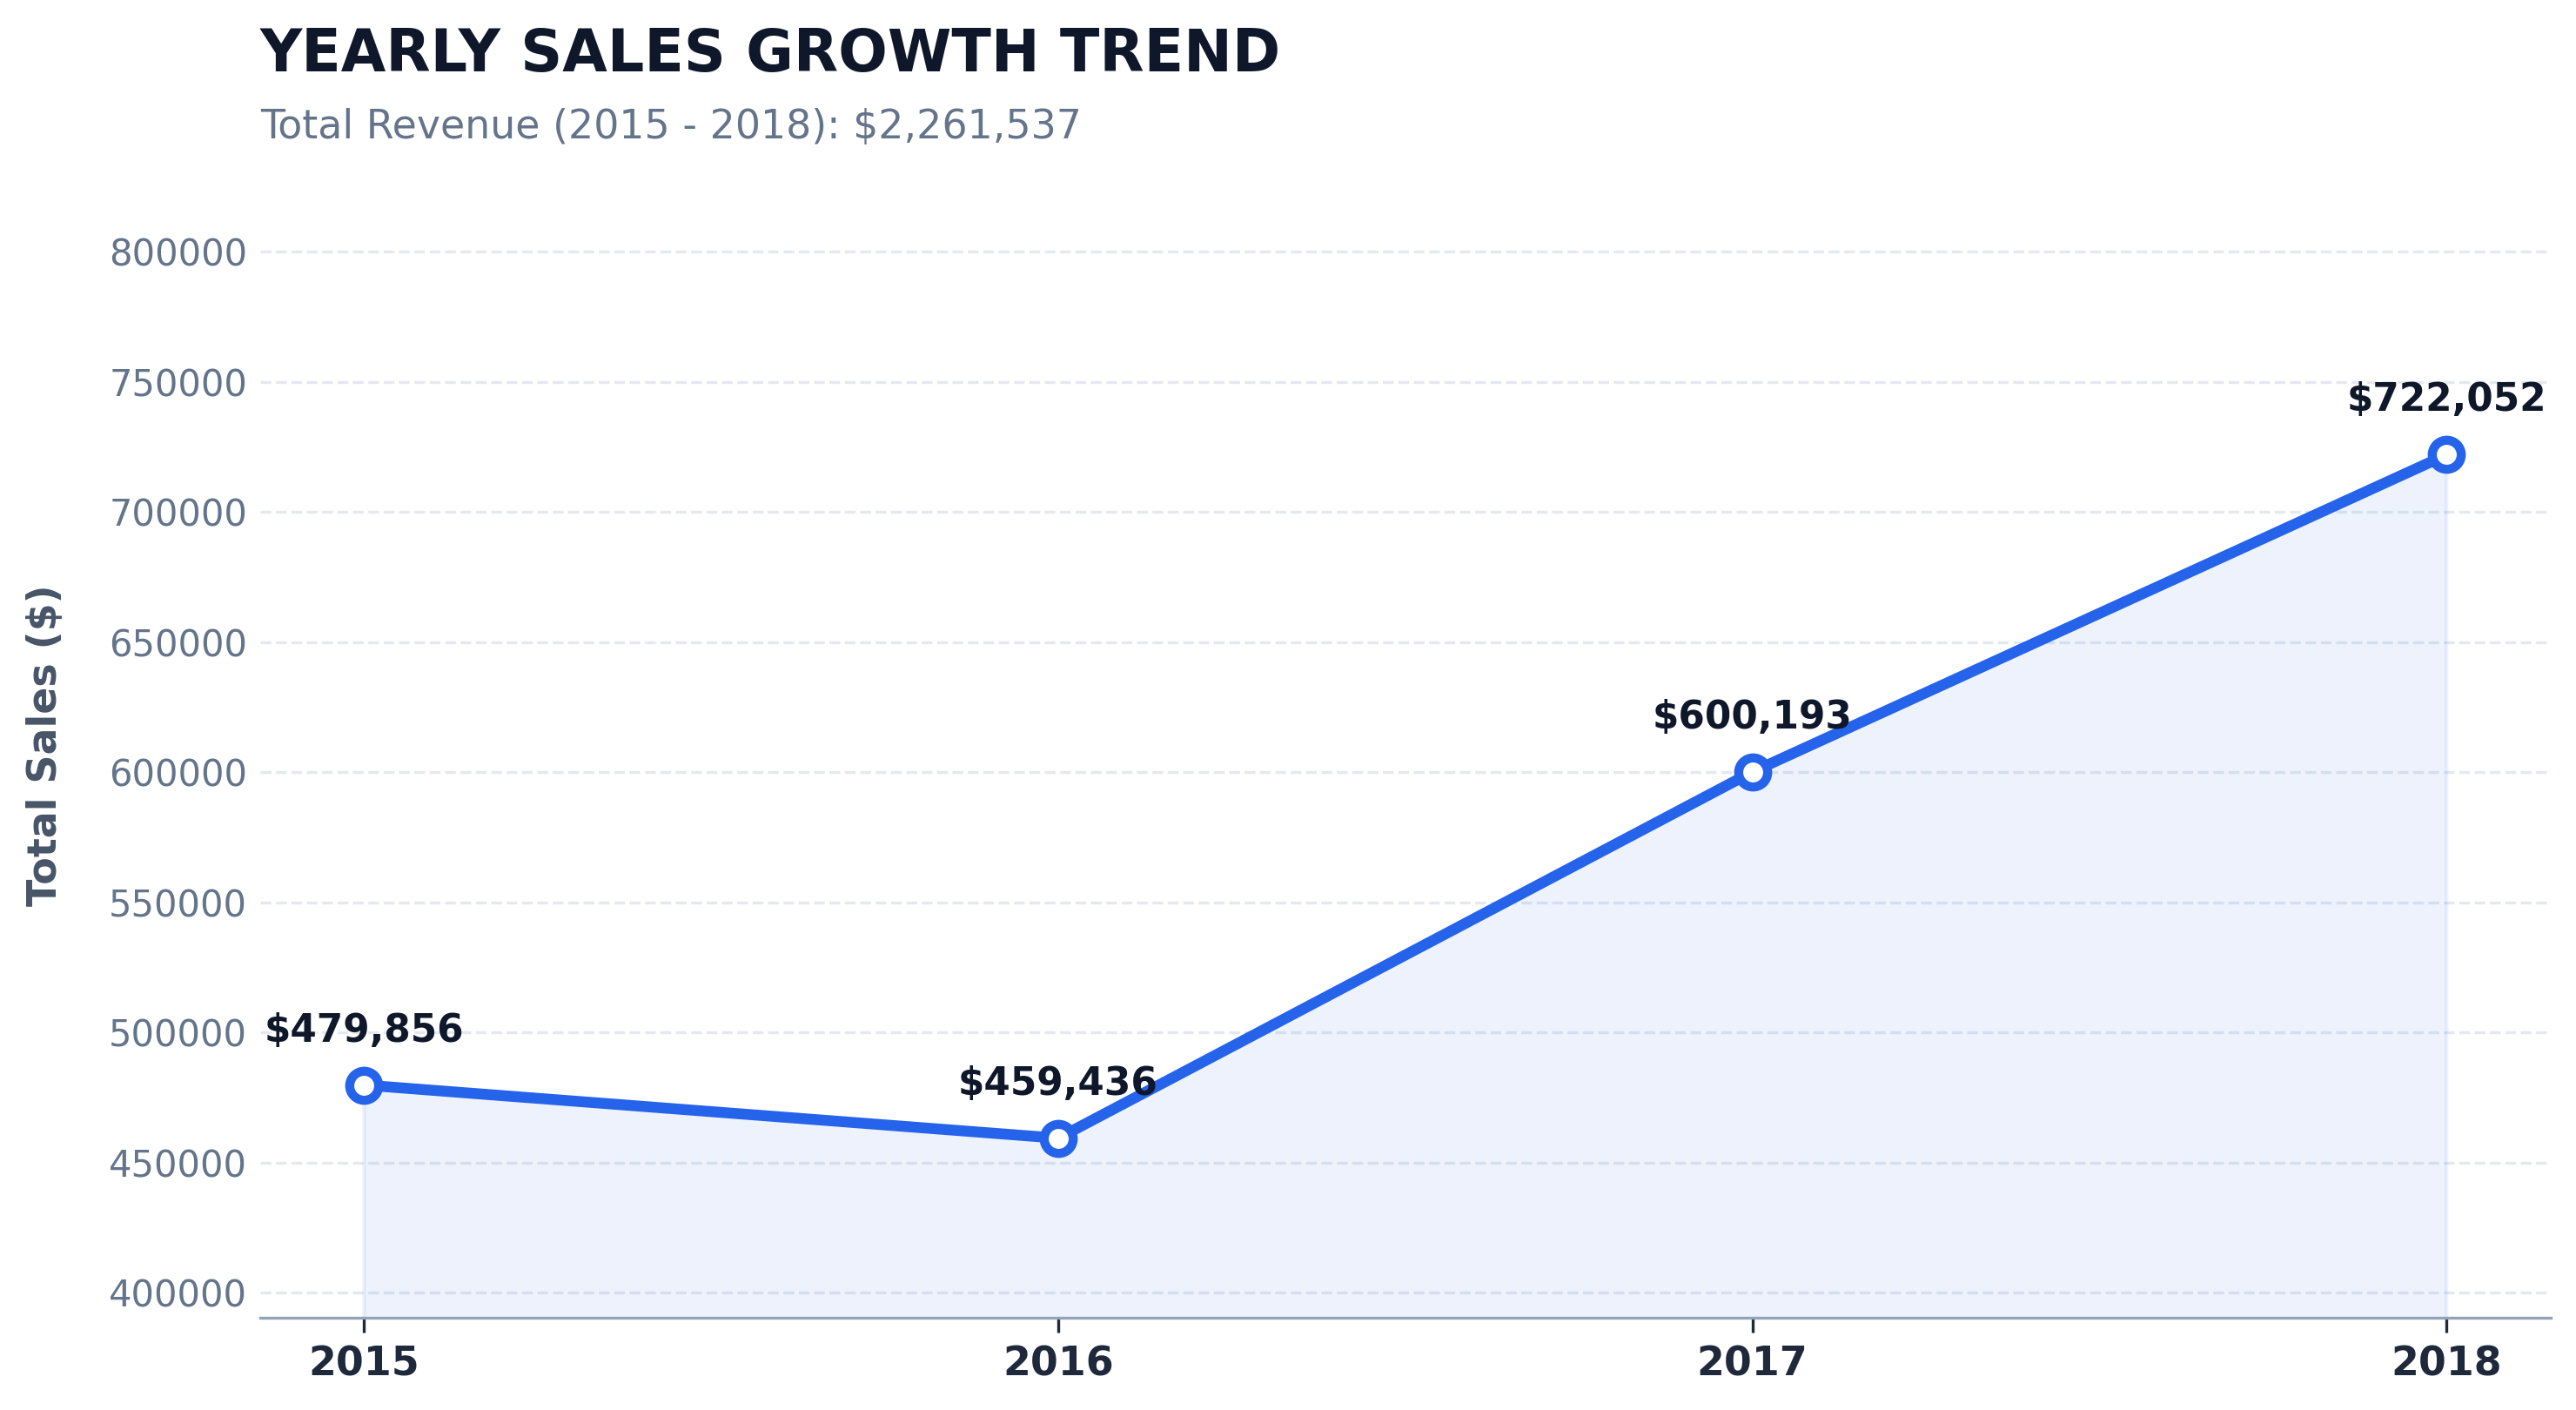

In [4]:
# 1. Data Aggregation
yearly_sales = df.groupby(df["Order_Date"].dt.year)["Sales"].sum()

# 2. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

# Main Trend Line
ax.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#2563EB",            # Vibrant Royal Blue
    markerfacecolor="#FFFFFF",   # Clean White Center
    markeredgewidth=2.5,
    markeredgecolor="#2563EB",
    zorder=3
)

# 3. Subtle Area Fill (Gives Depth to Trend)
ax.fill_between(
    yearly_sales.index,
    yearly_sales.values,
    color="#2563EB",
    alpha=0.08,
    zorder=2
)

# 4. Data Labels ($ values above each point)
for year, sales in yearly_sales.items():
    ax.annotate(
        f"${sales:,.0f}",
        (year, sales),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=10.5,
        fontweight="bold",
        color="#0F172A"
    )

# 6. Executive Header & Subtitle
plt.title("YEARLY SALES GROWTH TREND", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
growth_text = f"Total Revenue ({yearly_sales.index.min()} - {yearly_sales.index.max()}): ${yearly_sales.sum():,.0f}"
ax.text(0, 1.03, growth_text, transform=ax.transAxes, fontsize=11, color="#64748B", fontweight="medium")

# 7. Axes, Grid & Spines Styling
ax.set_ylabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=12, color="#475569")
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#CBD5E1", zorder=1)

# Hide the top, right, and left frame spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#94A3B8")

# X & Y Ticks Adjustment
ax.set_xticks(yearly_sales.index)
ax.tick_params(axis="y", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="x", labelsize=11, colors="#1E293B", length=4)
plt.xticks(fontweight="bold")

# Dynamic Y-Limit to ensure labels fit cleanly
ax.set_ylim(yearly_sales.min() * 0.85, yearly_sales.max() * 1.15)

plt.tight_layout()

# 8. Save & Display
plt.savefig(
    "../reports/charts/yearly_sales_trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Section B: Where Are the Sales Coming From?

- Which Category generates the most sales?
- Which Sub-Category performs the best?
- Which Region generates the most sales?
- Which State generates the most sales?
- Which cities are important for the business?

In [5]:
# Calculate total sales for each category and sort them from highest to lowest
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
) 
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

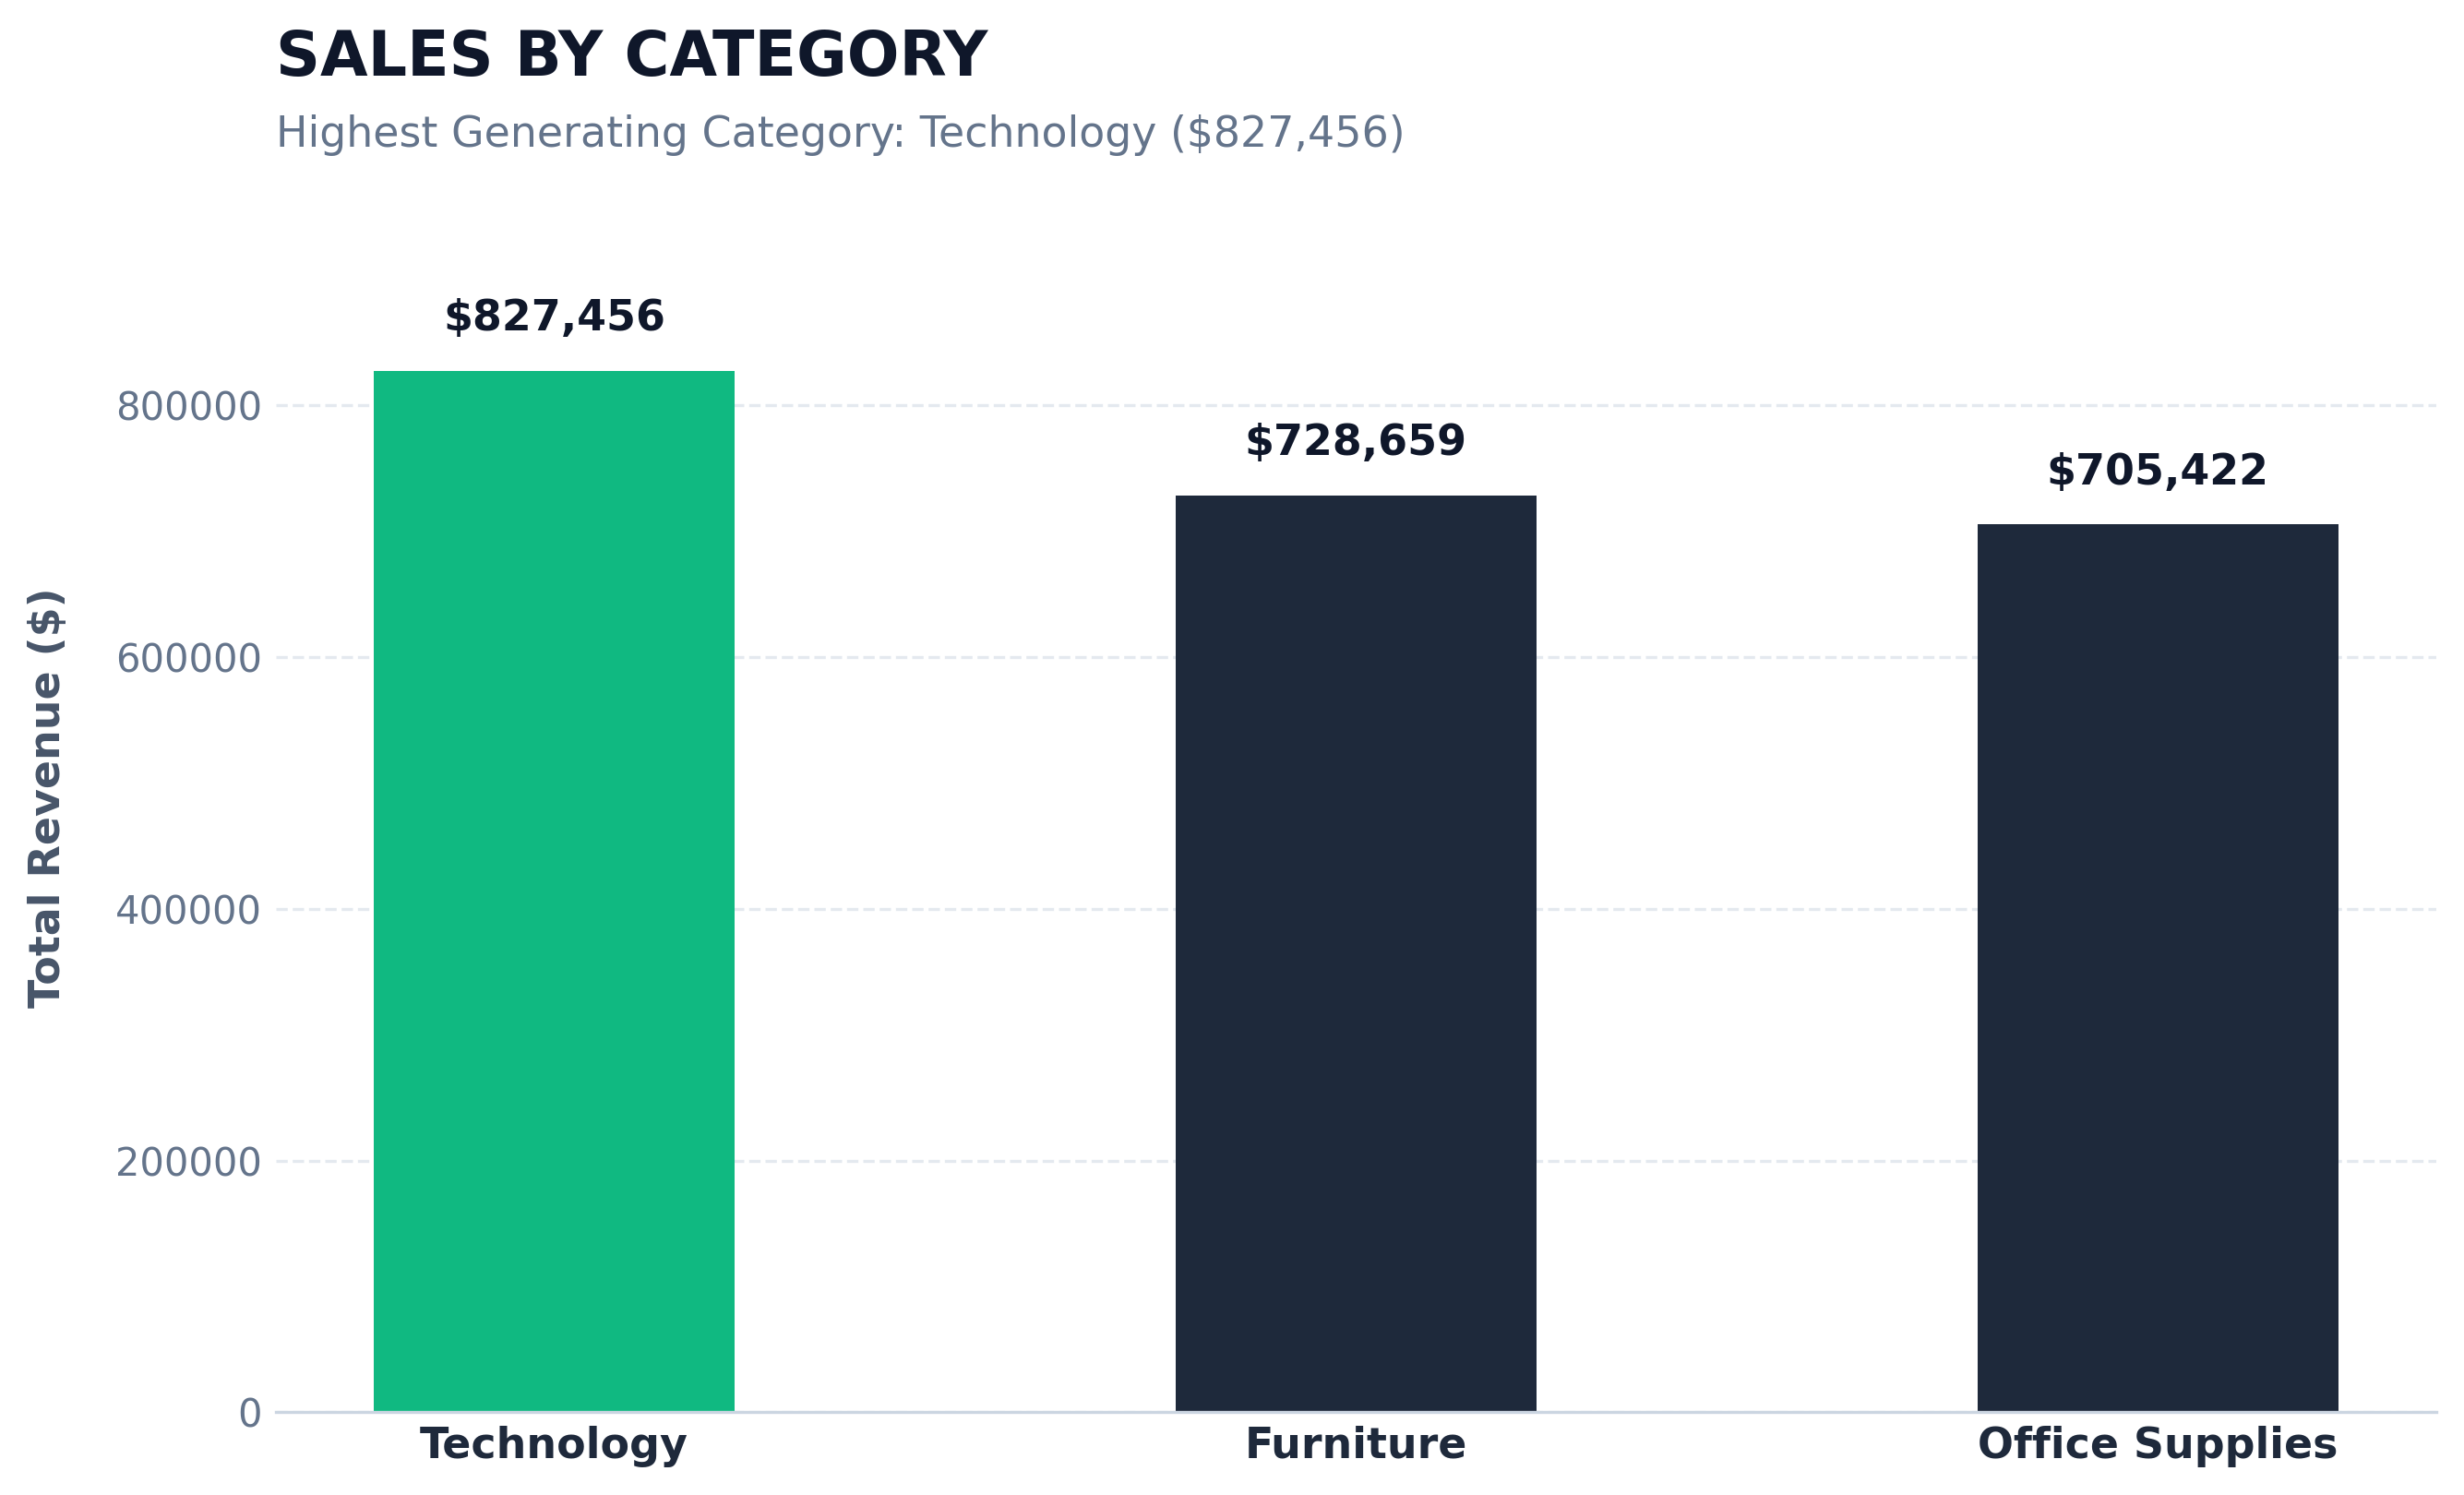

In [6]:
from pathlib import Path

# 1. Path Ensure
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# 2. Data Aggregation & Dynamic Highlight Color
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

best_category = category_sales.idxmax()

# Highlight the top category with vibrant emerald and the rest with dark slate blue
colors = ["#10B981" if cat == best_category else "#1E293B" for cat in category_sales.index]

# 3. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

bars = ax.bar(
    category_sales.index,
    category_sales.values,
    color=colors,
    width=0.45,  # Sleek bar width
    edgecolor="none"
)

# 4. Data Value Labels ($ Above Bars)
ax.bar_label(
    bars,
    labels=[f"${x:,.0f}" for x in category_sales],
    padding=8,
    fontsize=11,
    fontweight="bold",
    color="#0F172A"
)

# 5. Executive Header & Subtitle
plt.title("SALES BY CATEGORY", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
ax.text(
    0, 1.03, 
    f"Highest Generating Category: {best_category} (${category_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Clean Axes
ax.set_ylabel("Total Revenue ($)", fontsize=11, fontweight="bold", labelpad=12, color="#475569")
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)

# Hide the top, right, and left frame spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")

# Y-Axis Range Adjustment (To prevent labels from being cut off)
ax.set_ylim(0, category_sales.max() * 1.18)

# Ticks Styling
ax.tick_params(axis="y", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="x", labelsize=11, length=0)
plt.xticks(rotation=0, fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. High-Res Save
plt.savefig(
    "../reports/charts/category_sales.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

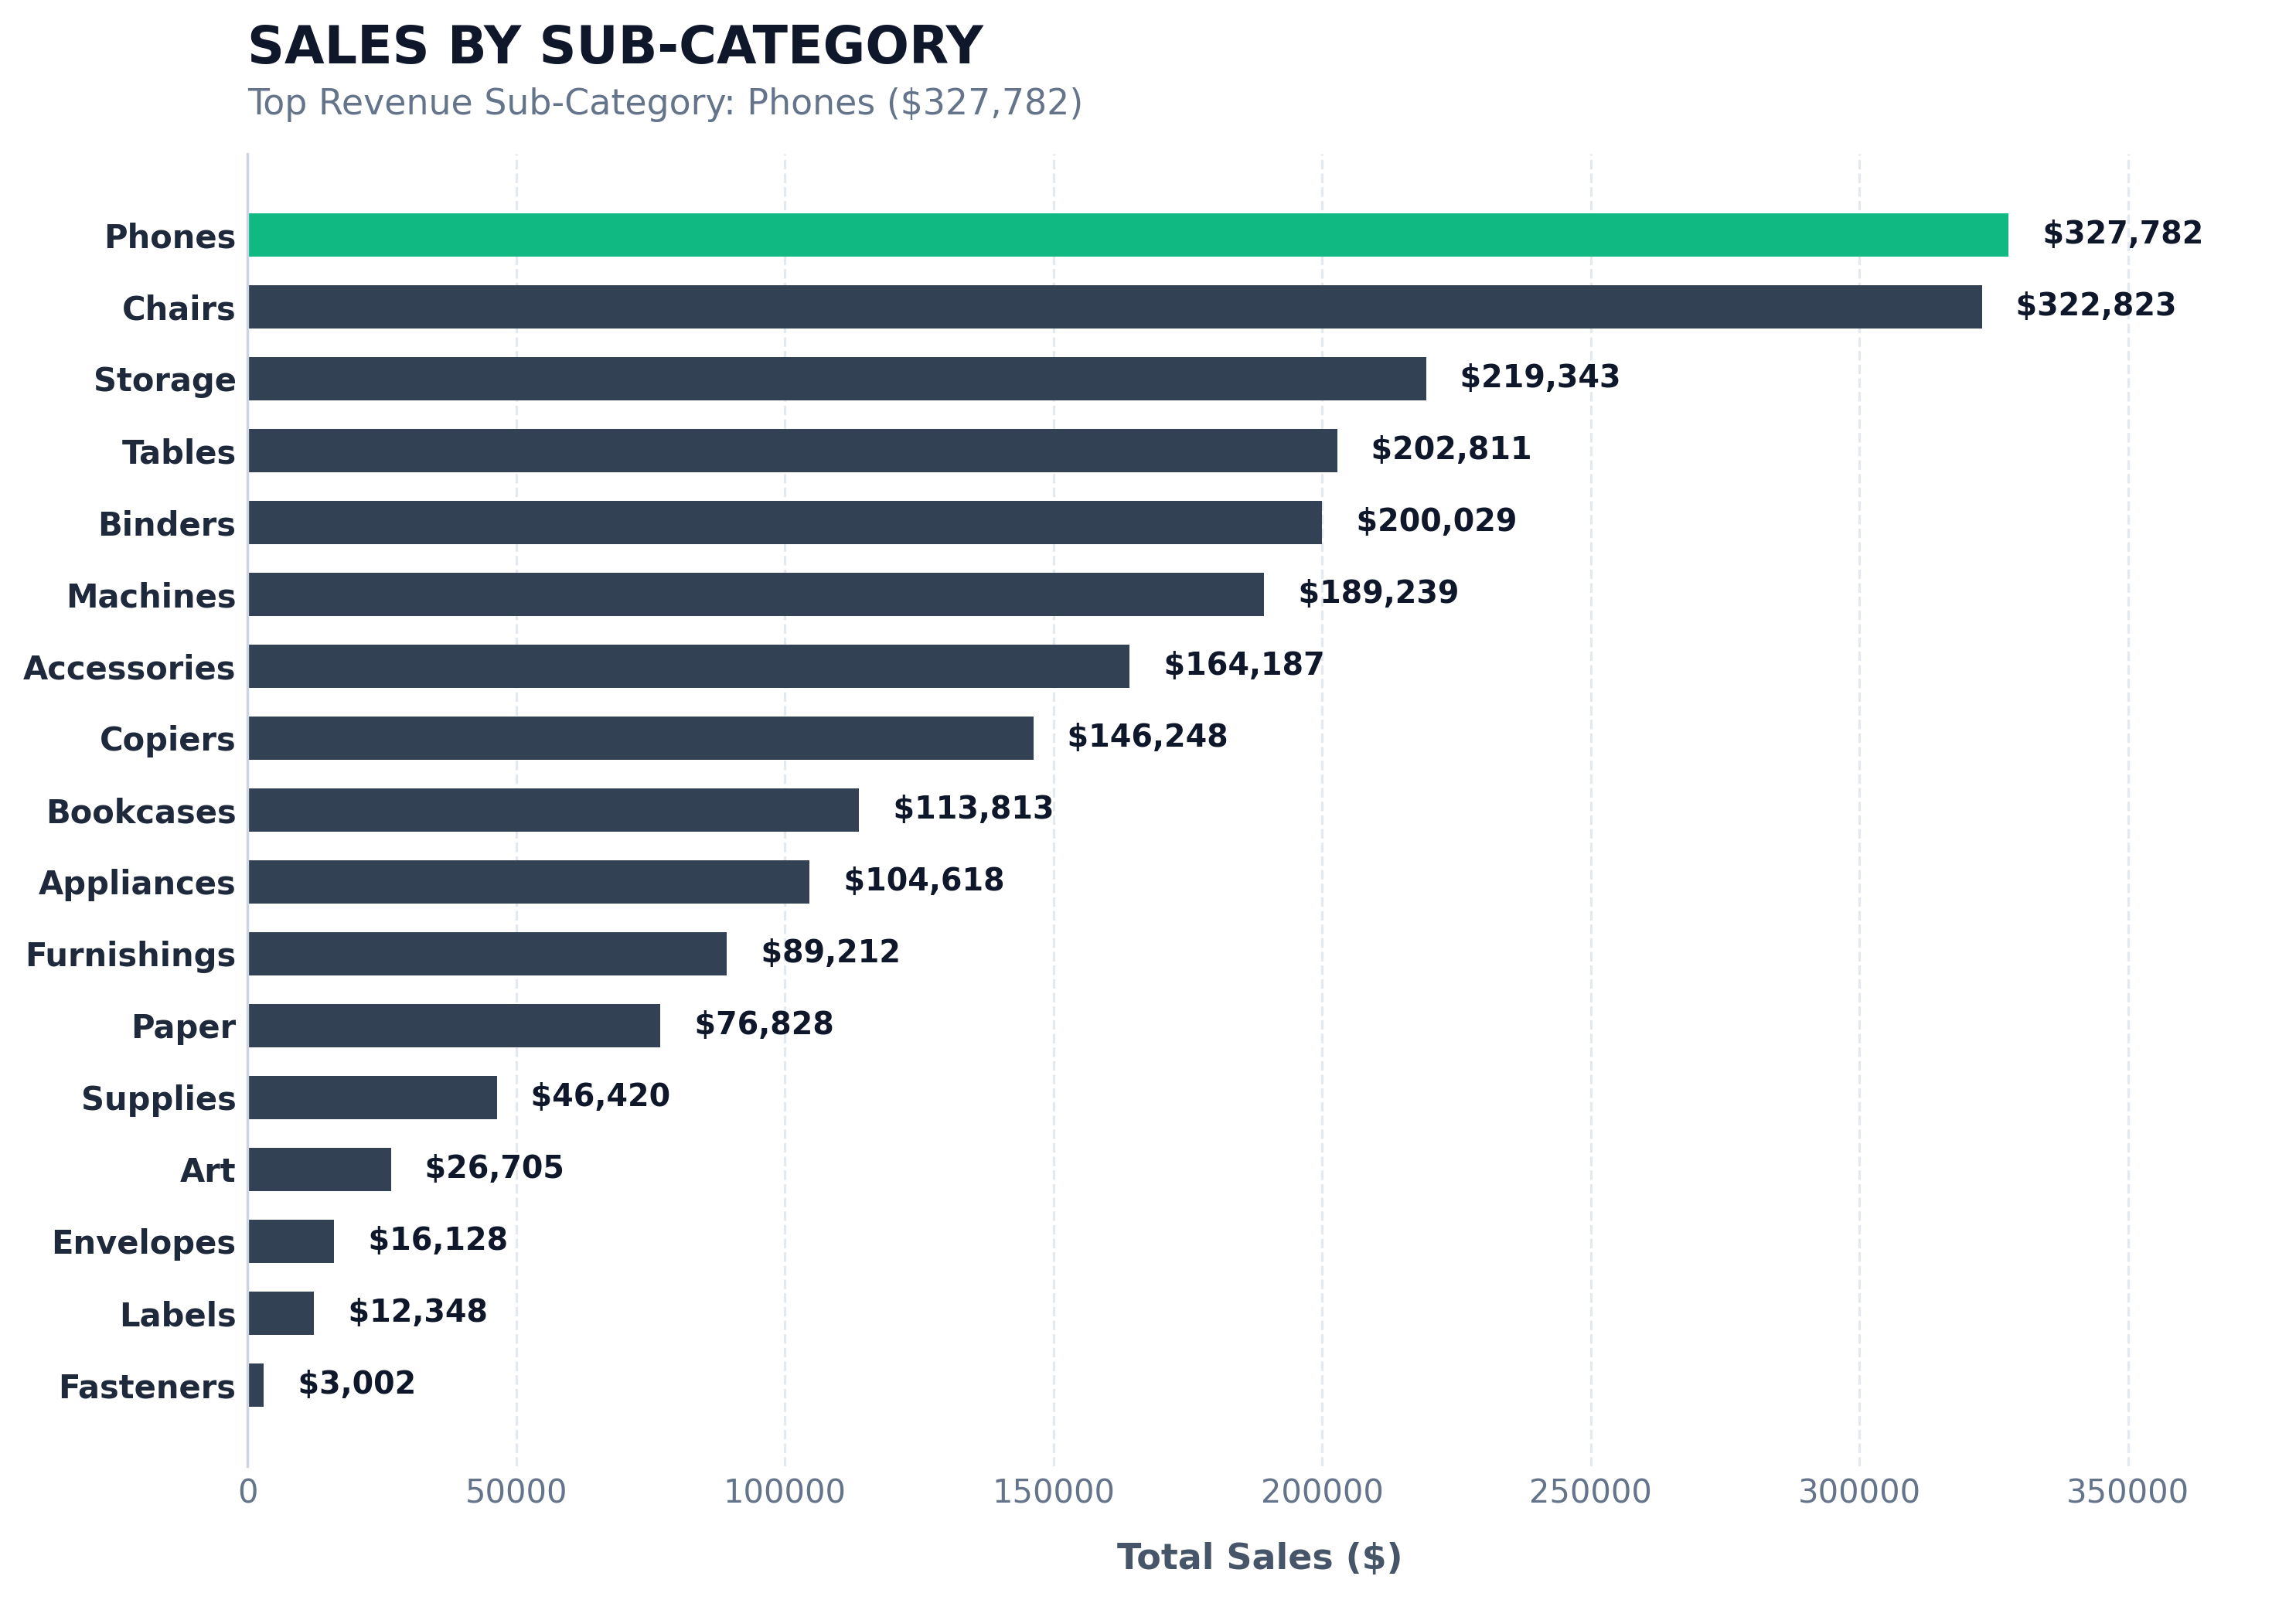

In [7]:
from pathlib import Path

# 1. Directory Check
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# 2. Data Aggregation & Ascending Order (Ascending order is better for horizontal bar charts)
subcat_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=True)  # Use ascending=True to display the top item at the top
)

best_subcat = subcat_sales.idxmax()

# Highlight the top sub-category with vibrant emerald and the rest with muted slate navy
colors = ["#10B981" if subcat == best_subcat else "#334155" for subcat in subcat_sales.index]

# 3. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

bars = ax.barh(
    subcat_sales.index,
    subcat_sales.values,
    color=colors,
    height=0.6,  # Clean slim bar height
    edgecolor="none"
)

# 4. Data Labels ($ Right Side of Bars)
ax.bar_label(
    bars,
    labels=[f"  ${x:,.0f}" for x in subcat_sales],
    padding=4,
    fontsize=9.5,
    fontweight="bold",
    color="#0F172A"
)

# 5. Executive Header & Subtitle
plt.title("SALES BY SUB-CATEGORY", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
ax.text(
    0, 1.03, 
    f"Top Revenue Sub-Category: {best_subcat} (${subcat_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Clean Axes
ax.set_xlabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10, color="#475569")
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)

# Hide the top, right, and bottom spines
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")

# X-Axis Range Adjustment (To prevent values from being cut off)
ax.set_xlim(0, subcat_sales.max() * 1.15)

# Ticks Styling
ax.tick_params(axis="x", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="y", labelsize=10, length=0)
plt.yticks(fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. High-Res Save
plt.savefig(
    "../reports/charts/subcategory_sales.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [8]:
# Calculate total sales for each region and sort them from highest to lowest
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

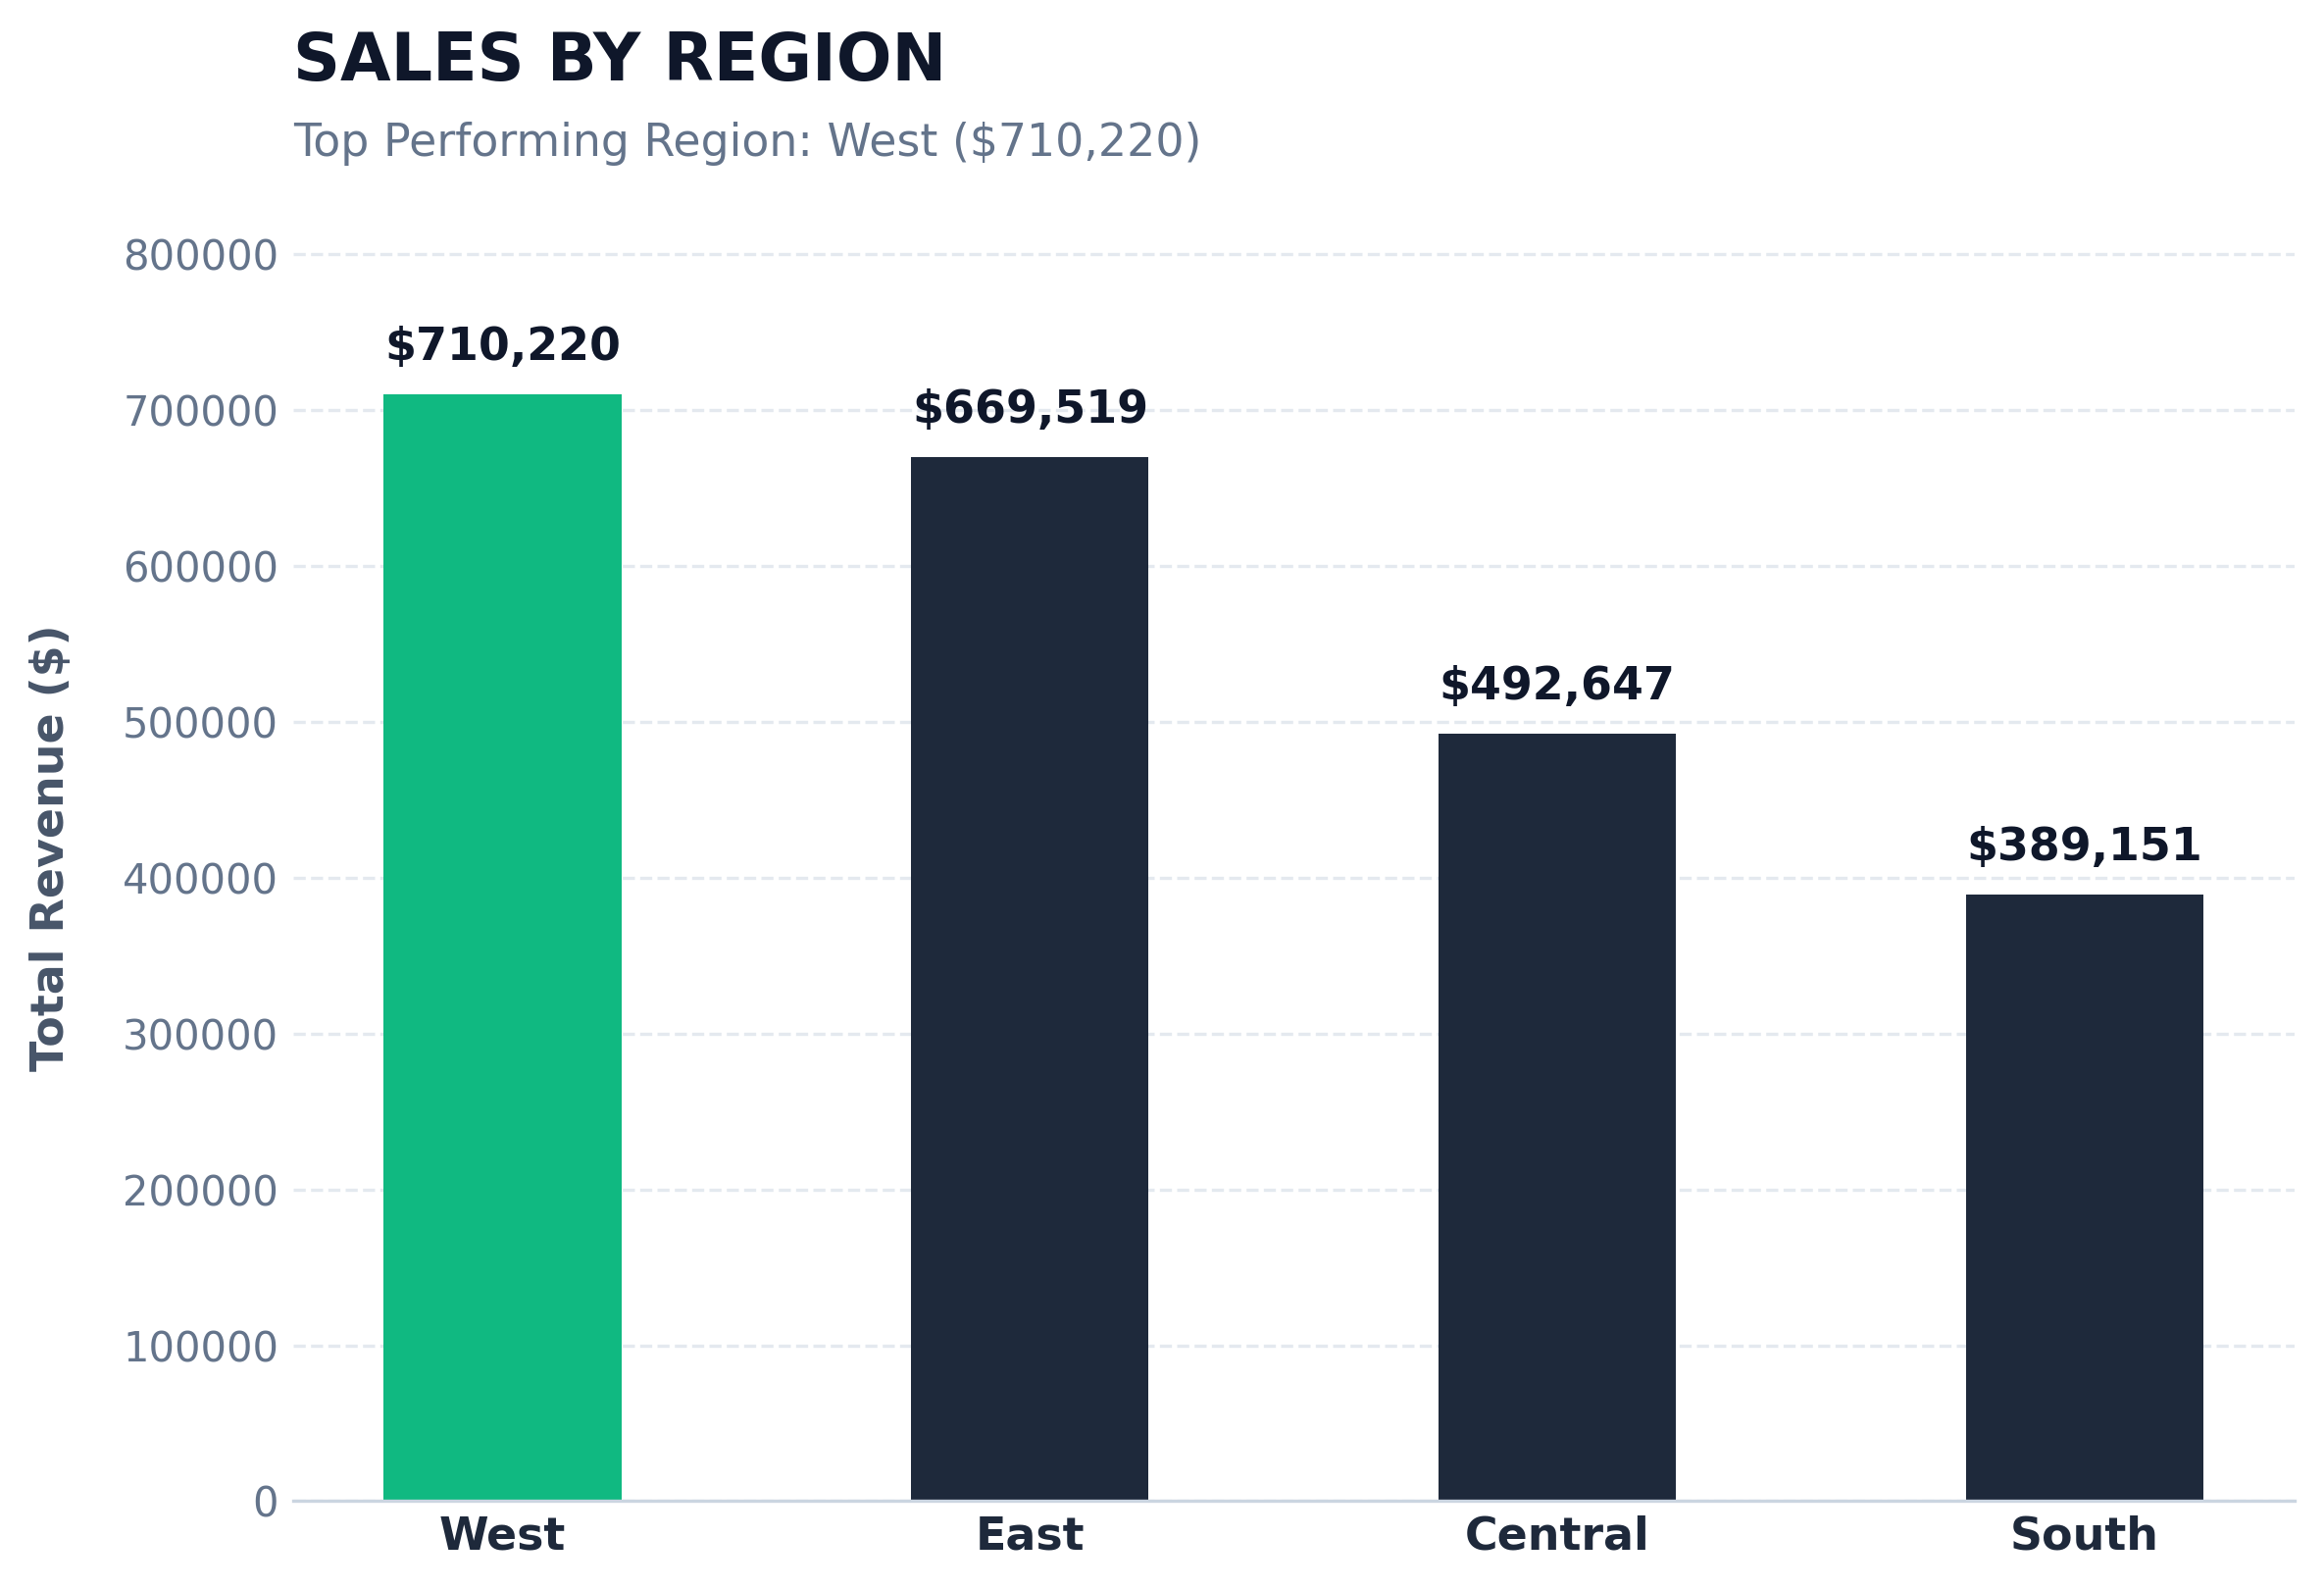

In [9]:
from pathlib import Path

# 1. Ensure Directory
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# 2. Data Aggregation & Dynamic Colors
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

best_region = region_sales.idxmax()

# Highlight the top region with emerald green and the rest with slate navy blue
colors = ["#10B981" if reg == best_region else "#1E293B" for reg in region_sales.index]

# 3. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)

bars = ax.bar(
    region_sales.index,
    region_sales.values,
    color=colors,
    width=0.45,  # Modern slim bar width
    edgecolor="none"
)

# 4. Data Value Labels ($ Above Bars)
ax.bar_label(
    bars,
    labels=[f"${x:,.0f}" for x in region_sales],
    padding=6,
    fontsize=11,
    fontweight="bold",
    color="#0F172A"
)

# 5. Executive Header & Subtitle
plt.title("SALES BY REGION", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
ax.text(
    0, 1.03, 
    f"Top Performing Region: {best_region} (${region_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Clean Axes
ax.set_ylabel("Total Revenue ($)", fontsize=11, fontweight="bold", labelpad=12, color="#475569")
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)  # Keep grid lines behind the bars

# Remove unnecessary frame spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")

# Y-Axis Range Fix (To prevent labels from being cut off)
ax.set_ylim(0, region_sales.max() * 1.18)

# Ticks Styling
ax.tick_params(axis="y", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="x", labelsize=11, length=0)
plt.xticks(rotation=0, fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. High Resolution Save
plt.savefig(
    "../reports/charts/region_sales.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

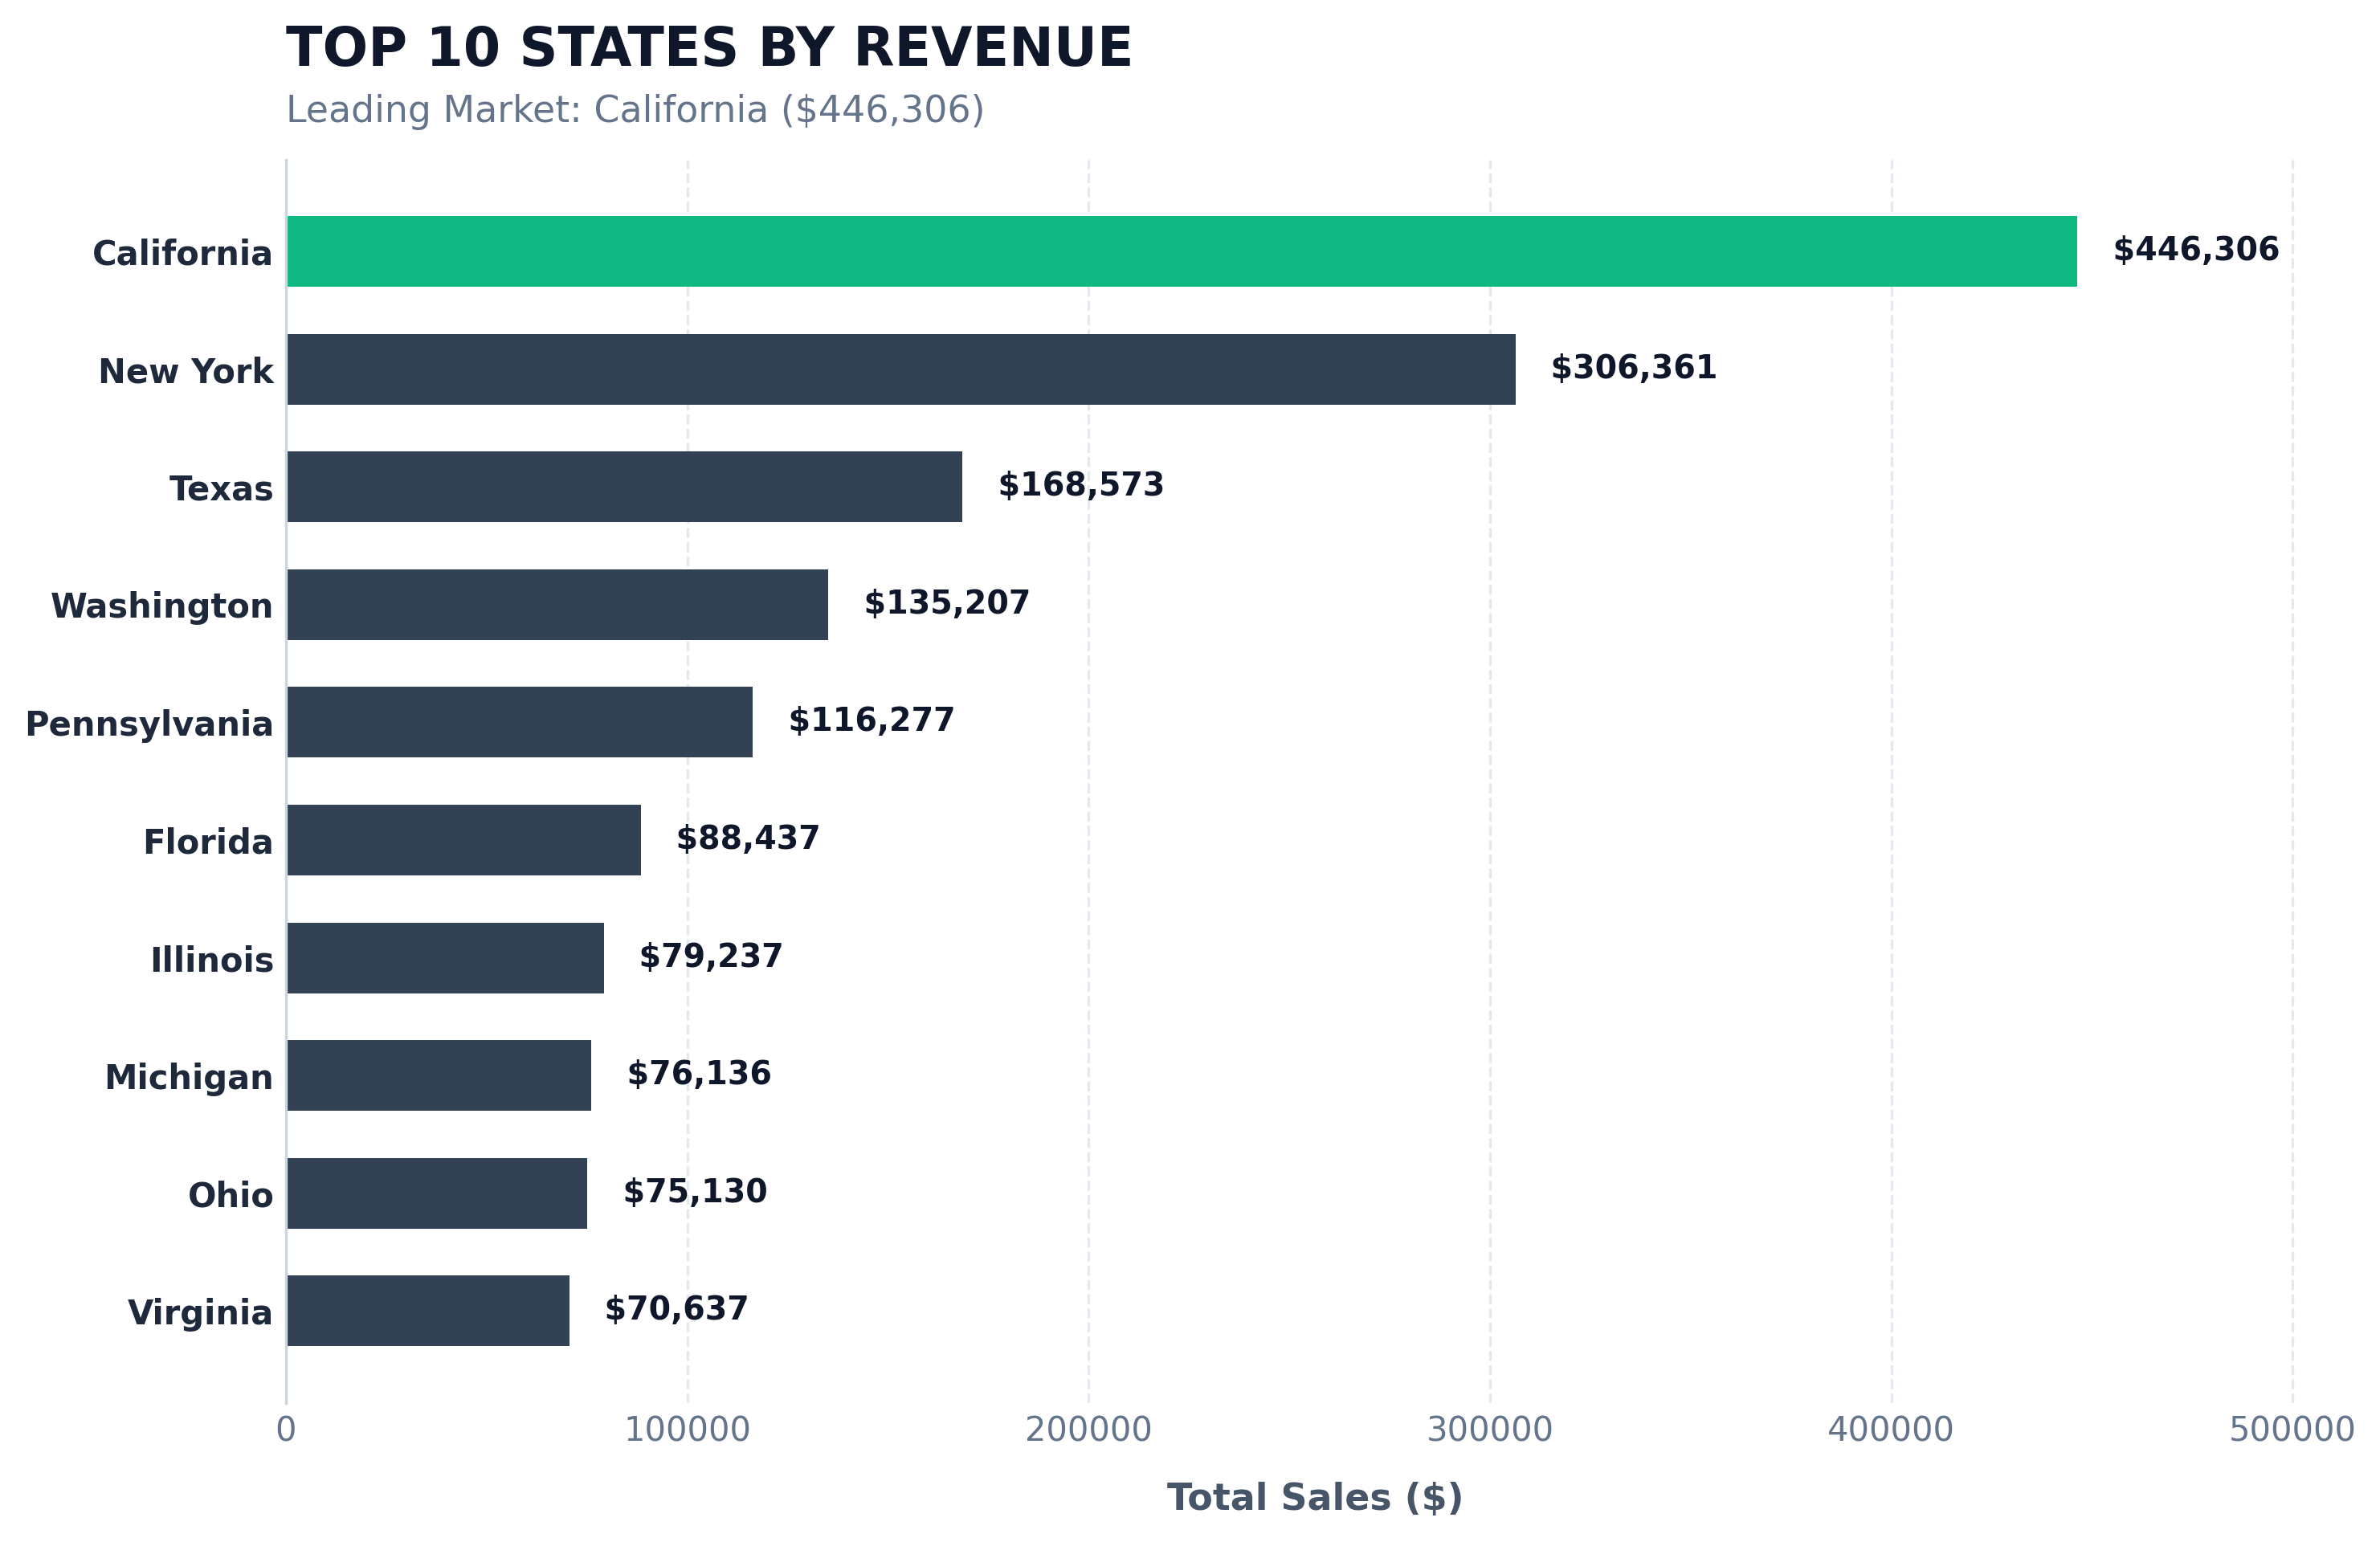

In [10]:
from pathlib import Path

# 1. Directory Check
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# 2. Data Aggregation (Ascending order for Horizontal Bar Chart)
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True) # Sort in ascending order so the #1 state appears at the top
)

best_state = state_sales.idxmax()

# Highlight the top state with vibrant emerald green and the remaining states with dark slate navy
colors = ["#10B981" if state == best_state else "#334155" for state in state_sales.index]

# 3. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

bars = ax.barh(
    state_sales.index,
    state_sales.values,
    color=colors,
    height=0.6, # Slim modern bar height
    edgecolor="none"
)

# 4. Data Labels ($ Value Right Side of Bars)
ax.bar_label(
    bars,
    labels=[f"  ${x:,.0f}" for x in state_sales],
    padding=4,
    fontsize=9.5,
    fontweight="bold",
    color="#0F172A"
)

# 5. Executive Header & Subtitle
plt.title("TOP 10 STATES BY REVENUE", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
ax.text(
    0, 1.03, 
    f"Leading Market: {best_state} (${state_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Axes Cleanup
ax.set_xlabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10, color="#475569")
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)

# Hide unnecessary spines
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")

# X-Axis Limit Adjustment (To prevent labels from being cut off)
ax.set_xlim(0, state_sales.max() * 1.15)

# Ticks Styling
ax.tick_params(axis="x", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="y", labelsize=10, length=0)
plt.yticks(fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. Save High-Res Chart
plt.savefig(
    "../reports/charts/top_states.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

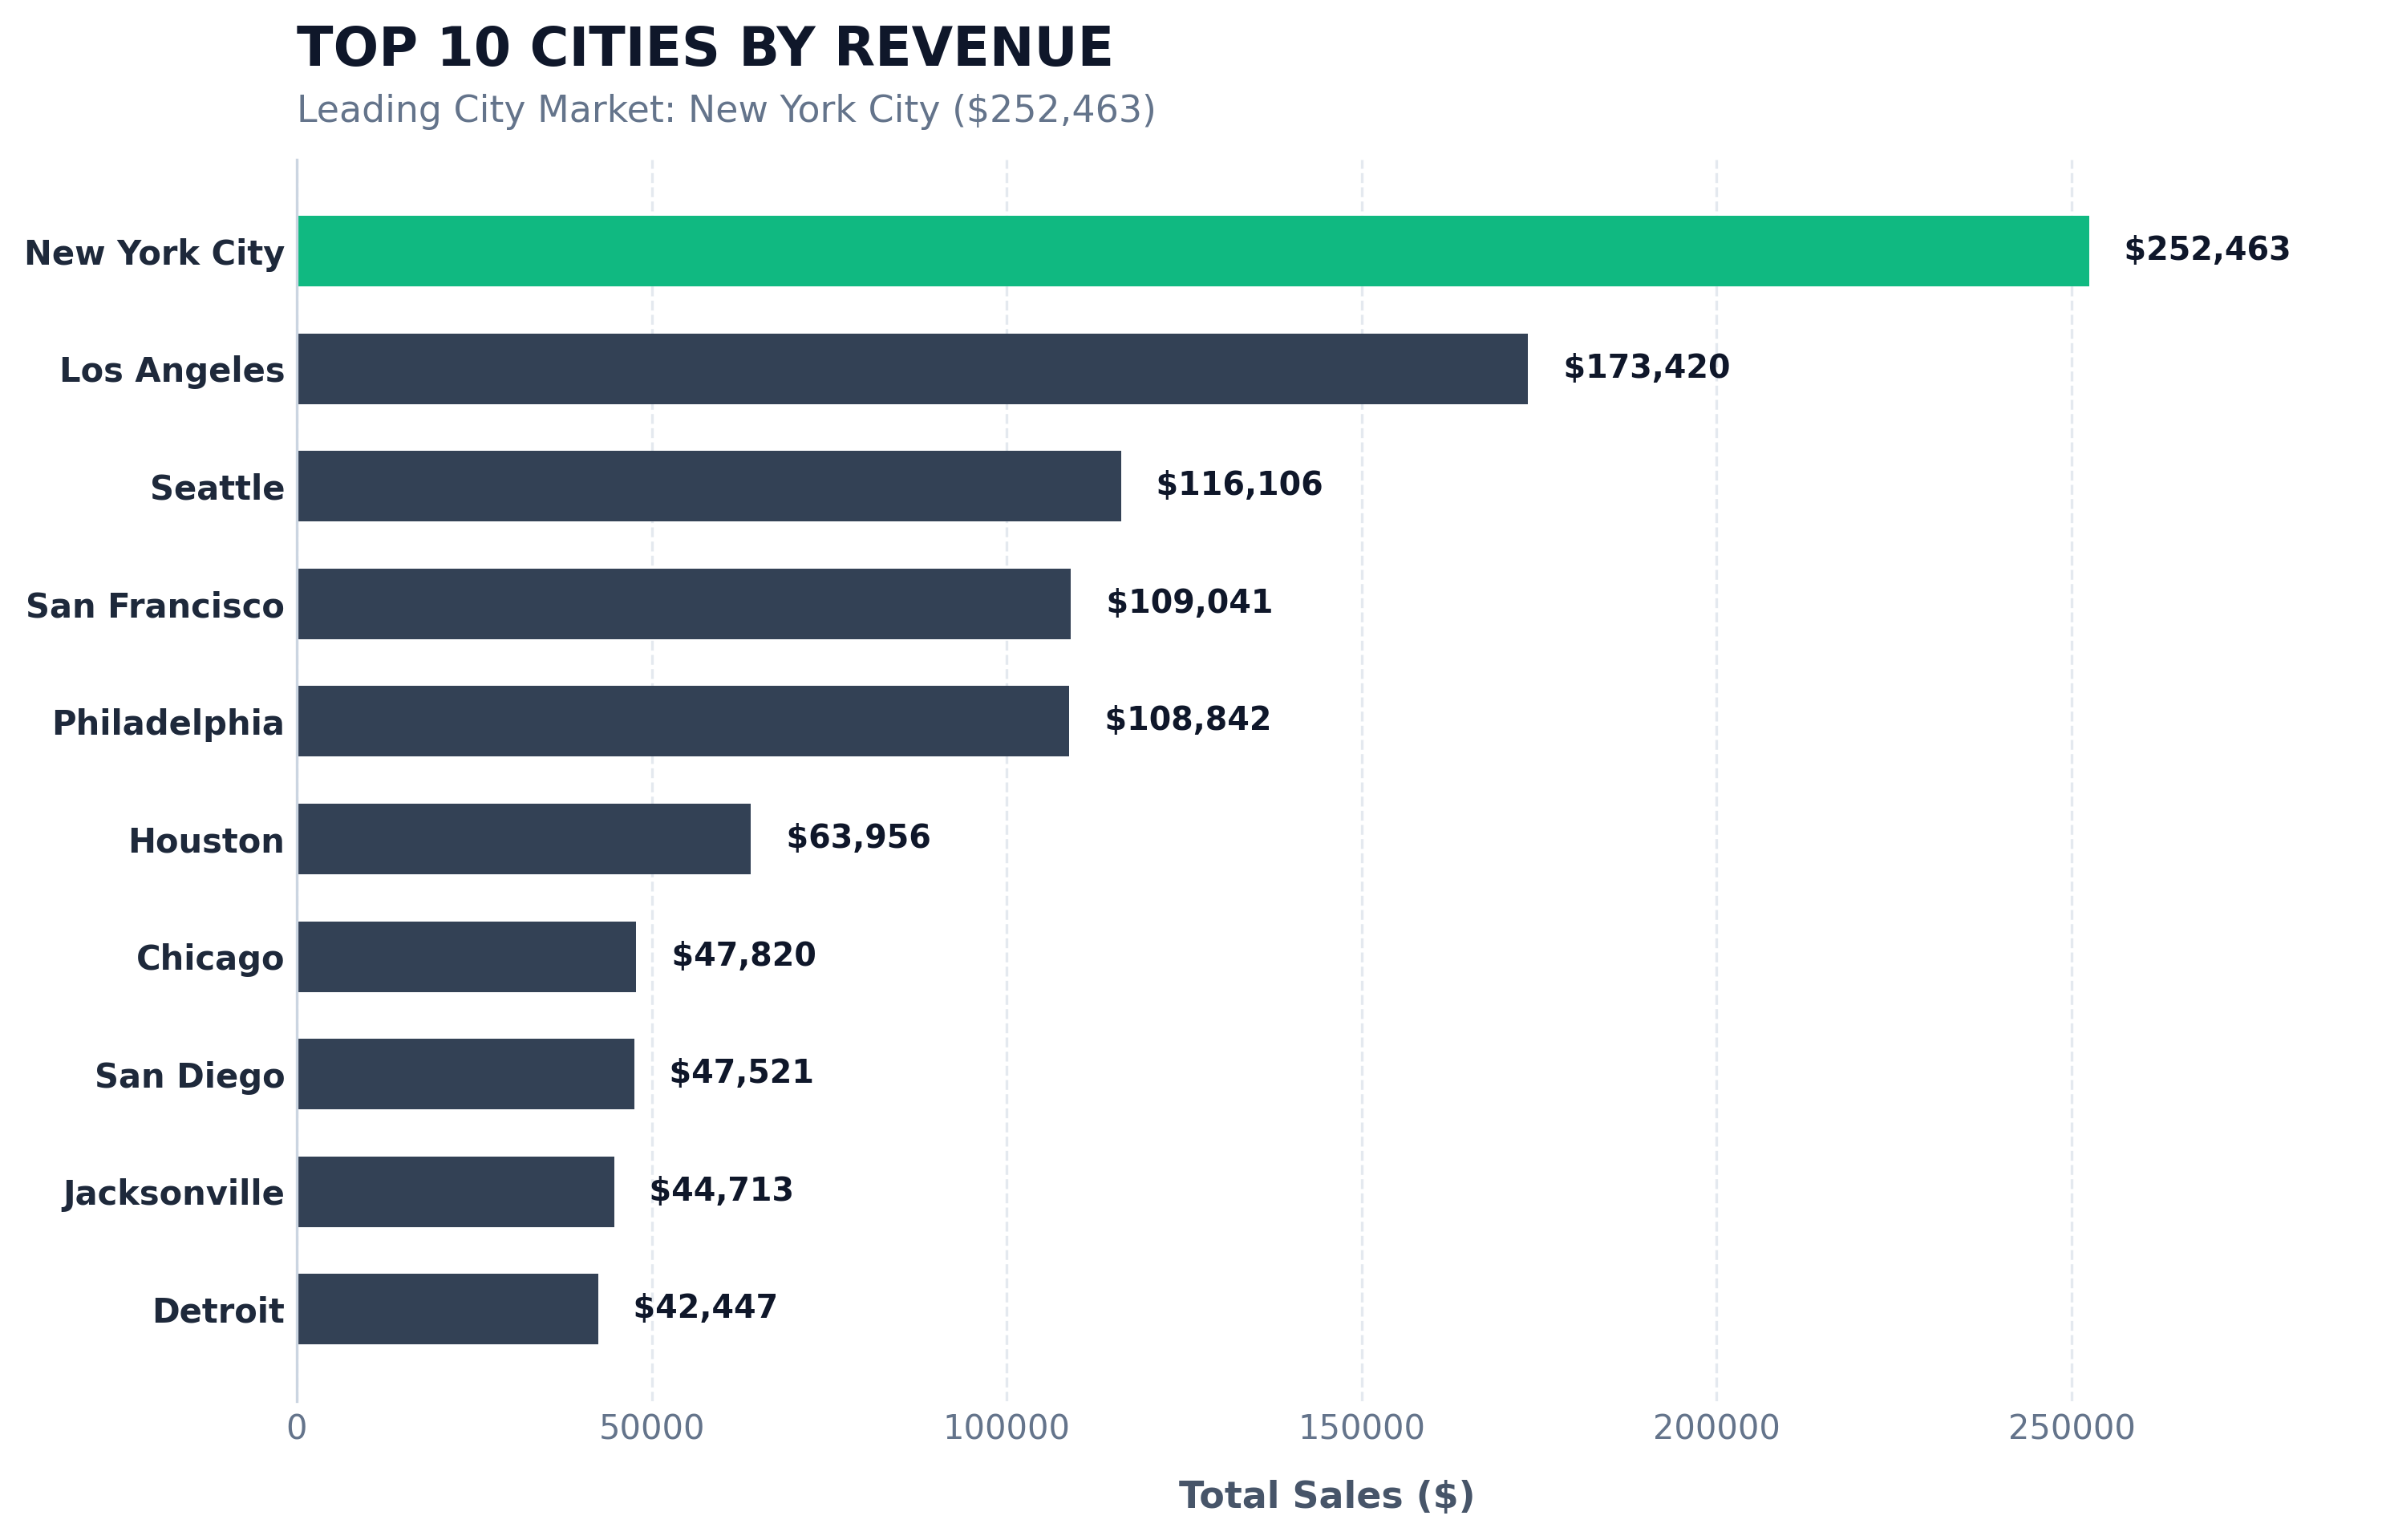

In [11]:
from pathlib import Path

# 1. Directory Check
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# 2. Data Aggregation (Ascending order for Horizontal Bar Chart)
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)  # Sort in ascending order so the #1 city appears at the top
)

best_city = city_sales.idxmax()

# Highlight the top city with vibrant emerald green and the remaining cities with dark slate navy
colors = ["#10B981" if city == best_city else "#334155" for city in city_sales.index]

# 3. Figure & Axis Setup (High DPI)
fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

bars = ax.barh(
    city_sales.index,
    city_sales.values,
    color=colors,
    height=0.6,  # Slim modern bar height
    edgecolor="none"
)

# 4. Data Labels ($ Value Right Side of Bars)
ax.bar_label(
    bars,
    labels=[f"  ${x:,.0f}" for x in city_sales],
    padding=4,
    fontsize=9.5,
    fontweight="bold",
    color="#0F172A"
)

# 5. Executive Header & Subtitle
plt.title("TOP 10 CITIES BY REVENUE", fontsize=16, fontweight="bold", pad=28, loc="left", color="#0F172A")
ax.text(
    0, 1.03, 
    f"Leading City Market: {best_city} (${city_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Axes Cleanup
ax.set_xlabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10, color="#475569")
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)

# Hide unnecessary spines
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")

# X-Axis Limit Adjustment (To prevent labels from being cut off)
ax.set_xlim(0, city_sales.max() * 1.15)

# Ticks Styling
ax.tick_params(axis="x", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="y", labelsize=10, length=0)
plt.yticks(fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. Save High-Res Chart
plt.savefig(
    "../reports/charts/top_cities.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 📊 Business Performance Summary

### Overall Performance
- Total Sales: $2,261,536.78
- Total Orders: 4,922
- Unique Customers: 793
- Unique Products: 1,861
- Sales trend: Overall increasing from 2015 to 2018, with a temporary decline in 2016

### Where Sales Are Coming From
- **Top Category:** Technology generates the highest sales (36.59% of total)
- **Top Sub-Category:** Phones
- **Top Region:** West region is the strongest market
- **Top State:** California
- **Top Cities:** New York City, Los Angeles, Seattle

### 💡 Business Insight
Technology and West together represent the core of the business's revenue. 
This suggests marketing and inventory efforts should prioritize these areas, 
while underperforming categories/regions may need targeted promotions or 
further investigation into low performance.